# Projekt 4: Własne środowisko

**Autorzy:** Emilia Sarna, Kalina Rączka

**Data:** 14.05.2026

## Implementacja Środowiska i Problemu

### Opis Gry: „CatchBrains”

Gra jest środowiskiem typu catch-and-avoid (złap i unikaj), w którym agent steruje postacią zombie poruszającą się w osi poziomej ($x$). Celem gry jest zbieranie spadających mózgów (nagroda dodatnia) przy jednoczesnym unikaniu innych części ciała (kara + utrata życia).



### Kluczowe Komponenty Techniczne
- **Złożone Spritesheets**: Stworzono klasę SpriteSheet do obsługi animacji klatkowych. System obsługuje dynamiczne skalowanie oraz odbicia lustrzane, co pozwala na płynne renderowanie ruchu zombie w obu kierunkach oraz sekwencji specjalnych (powstawanie z grobu na starcie, animacja śmierci).
- **Mechanika Kolizji (Catch Zone)**: Zaimplementowano strefę „Catch Zone” obejmującą górną połowę ciała zombie. Przedmiot jest uznany za złapany tylko wtedy, gdy jego środek znajdzie się wewnątrz tej strefy przy zachowaniu odpowiedniego pokrycia w osi poziomej.
- **Dynamika Trudności:** Środowisko posiada mechanizm SLOWDOWN, który liniowo zmniejsza bazową prędkość ruchu zombie wraz ze wzrostem wyniku, co zmusza agenta do bardziej precyzyjnego pozycjonowania się pod spadającymi obiektami w miarę postępu gry.
- **Wizualizacja i Multimedia:** Gra wykorzystuje bibliotekę OpenCV do odtwarzania animacji wprowadzającej w formacie .mp4 oraz system HUD renderowany w czasie rzeczywistym (licznik punktów, paski życia w formie serc).

In [ ]:
class CatchBrainsEnv(gym.Env):

    def __init__(self, render_mode=None, lives=5, window_w=600, window_h=700):
        self.window_w = window_w
        self.window_h = window_h
        self.game_h = window_h - HUD_HEIGHT
        self.max_lives = lives
        self.render_mode = render_mode

        obs_low = np.zeros(11, dtype=np.float32)
        obs_high = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        assert render_mode is None or render_mode in self.metadata["render_modes"]

        self._window: Optional[pygame.Surface] = None
        self._clock: Optional[pygame.time.Clock] = None
        self._assets_loaded = False
        self._first_reset = True

        self.zombie_x = float(window_w // 2)
        self.items: list[FallingItem] = []
        self.score = 0.0
        self.lives = lives
        self._steps = 0
        self._spawn_counter = 0
        self._is_moving = False
        self._facing_right = False
        self._walk_frame = WALK_IDLE_FRAME
        self._walk_timer = 0

Metoda step(self, action) odpowiada za przejście środowiska ze stanu $S_t$ do stanu $S_{t+1}$ na podstawie akcji agenta $A_t$. Proces ten można podzielić na pięć kluczowych faz:

1. **Obsługa Akcji i Ruch Agenta** <br>W tej fazie ciągła wartość akcji (z zakresu $[-1, 1]$) jest mapowana na konkretny ruch w silniku Pygame:<br>- Decyzja o kierunku: Na podstawie znaku wartości akcji ustawiane są flagi wizualne (_facing_right, _is_moving), które sterują animacją zombie.<br>- Dynamiczna prędkość: Prędkość poruszania się jest przeliczana wzorem:$$\text{speed} = \frac{\text{BASE\_SPEED}}{\max(1.0, 1.0 + \text{score} \times \text{SLOWDOWN})}$$Powoduje to, że wraz z postępem gry postać staje się ociężała, co utrudnia łapanie obiektów.<br>- Walidacja pozycji: Nowa pozycja $x$ jest ograniczana (np.clip) do szerokości okna, aby agent nie wyszedł poza obszar gry.

2. **Aktualizacja Świata (Fizyka Przedmiotów)**<br>Dla każdego obiektu na liście self.items:<br>- Ruch w pionie: Współrzędna $y$ jest zwiększana o indywidualną prędkość przedmiotu.<br>- Animacja klatkowa: Jeśli przedmiot jest mózgiem, aktualizowany jest jego wewnętrzny timer animacji, co pozwala na renderowanie pulsujących/obracających się obiektów.

3. **Zarządzanie Populacją Obiektów (Spawning)**<br>System sprawdza, czy upłynął interwał SPAWN_INTERVAL oraz czy liczba obiektów na ekranie nie przekracza limitu. Jeśli warunki są spełnione, wywoływana jest metoda _spawn_item(), która tworzy nowy obiekt o losowych parametrach (typ, rozmiar, prędkość, pozycja).

4. **Detekcja Kolizji i "Catch Zone"**<br>To najbardziej krytyczny fragment kodu. Zamiast standardowej kolizji "pudełkowej" (Bounding Box), zastosowano dwuetapową weryfikację: <br> - Faza Y: Sprawdzenie, czy środek przedmiotu znajduje się wewnątrz wirtualnej strefy łapania (zombie_top_y do catch_zone_bottom).<br>- Faza X (Overlap): Jeśli wysokość jest poprawna, sprawdzane jest nachodzenie na siebie obiektów w poziomie z uwzględnieniem marginesu błędu:$$\text{dist}_x \leq \frac{W_{\text{zombie}}}{2} + \frac{W_{\text{item}}}{2}$$<br>- Wynik kolizji: Złapanie mózgu zwiększa wynik i nagrodę, natomiast złapanie "części ciała" odejmuje życie i nakłada wysoką karę punktową.

5. **Wyliczanie wyniku (score)**<br>Podczas każdego kroku aktualizowany jest wynik $score$, który jest niezbędny do pomyślnego zakończenia gry.<br>- jeżeli mózg został przechwycony przez naszego zombie, gracz dostaje 10 punktów<br>- jeżeli gracz pominie jakiś mózg, od wyniku odejmowane jest 15 punktów<br>- jeżeli gracz nie zbierze pozostałych części ciała, nic się nie dzieje

6. **Warunki Zakończenia i Sygnał Zwrotny**<br>Na końcu metody sprawdzany jest stan self.lives. Jeśli spadnie do zera, ustawiana jest flaga terminated = True, a agent otrzymuje karę terminalną (-50), w takim wypadku gra uzwana jest za przegraną. Wygraną osiąga się po zdobyciu 100 punktów ($score$) Metoda zwraca:<br>- Observation: Nowy stan środowiska (wektor 11 wartości).<br>- Reward: Sumaryczną nagrodę za dany krok, która jest potrzebna do późniejszego trenowania agenta.<br>- Terminated/Truncated: Flagi zakończenia epizodu.<br>- Info: Słownik z metrykami pomocniczymi (wynik, życia).

In [ ]:
# początkowy step, bez ulepszonej metody zdobywania kar i nagród
def step(self, action):
        act = float(action[0])
        if act > 0.01:
            self._facing_right = True
            self._is_moving = True
        elif act < -0.01:
            self._facing_right = False
            self._is_moving = True
        else:
            self._is_moving = False

        speed = BASE_SPEED / max(1.0, 1.0 + self.score * SLOWDOWN)
        self.zombie_x = float(np.clip(self.zombie_x + act * speed, 0, self.window_w))

        # advance items
        for item in self.items:
            item.y += item.speed
            if item.item_type == "brain" and item.images:
                item.anim_timer += 1
                if item.anim_timer >= 6:
                    item.anim_frame = (item.anim_frame + 1) % len(item.images)
                    item.anim_timer = 0

        # spawn
        self._spawn_counter += 1
        if self._spawn_counter >= SPAWN_INTERVAL and len(self.items) < MAX_ITEMS_ON_SCREEN:
            self._spawn_counter = 0
            self._spawn_item()

        # catch zone: top half of zombie body
        zombie_top_y = self.game_h - ZOMBIE_H
        catch_zone_bottom = self.game_h - ZOMBIE_H // 2

        reward = 0.0
        terminated = False
        still_falling = []

        for item in self.items:
            item_center_y = item.y + item.size // 2
            item_center_x = item.x

            if item_center_y < zombie_top_y:
                # still above zombie
                still_falling.append(item)
                continue

            if item_center_y <= catch_zone_bottom:
                # inside catch zone — check horizontal overlap
                horizontal_ok = abs(item_center_x - self.zombie_x) <= ZOMBIE_W // 2 + item.size // 2
                if horizontal_ok:
                    if item.item_type == "brain":
                        self.score += 10
                        reward += 10
                    else:
                        self.lives -= 1
                        reward -= 15
                    # caught — remove from list
                else:
                    still_falling.append(item)  # still in zone, not aligned yet
            else:
                # passed below catch zone without being caught
                if item.item_type == "brain":
                    self.score -= 10
                    reward -= 5
                # bodypart miss: no penalty

        self.items = still_falling

        if self.lives <= 0:
            reward -= 50
            terminated = True
        elif self.score >= MAX_SCORE:
            reward += 100 
            terminated = True
            print("Zwycięstwo! Osiągnięto limit punktów.")

        self._steps += 1

        if self.render_mode == "human":
            self._render_frame()
            if terminated:
                self._play_death()

        return self._get_obs(), reward, terminated, False, {"score": self.score, "lives": self.lives}

## Specyfikacja Reinforcement Learning

**Przestrzeń Akcji (Action Space)**

Zastosowano ciągłą przestrzeń akcji typu Box(-1.0, 1.0). Wartość skalarna decyduje o kierunku i sile ruchu:
- $[-1.0, -0.01]$: Ruch w lewo.
- $[-0.01, 0.01]$: Brak ruchu (idle).
- $[0.01, 1.0]$: Ruch w prawo.

**Przestrzeń Obserwacji (Observation Space)** 

Agent otrzymuje wektor 11 wartości znormalizowanych do zakresu $[0, 1]$:
- Pozycja $x$ zombie.
- Dane o 3 najbliższych przedmiotach (dla każdego: pozycja $x$, pozycja $y$, typ obiektu).
- Aktualna liczba żyć.Algorytm: PPO (Proximal Policy Optimization)

Do nauki wykorzystano algorytm PPO z biblioteki Stable Baselines3. Wybór ten podyktowany był:
- Stabilnością uczenia w ciągłych przestrzeniach akcji.
- Odpornością na gwałtowne zmiany strategii dzięki mechanizmowi clippingu (ograniczenia aktualizacji parametrów).
- Wydajnością w środowiskach, gdzie sygnał nagrody jest częściowo rzadki.

Finalnie, by dojść do odpowiedniego modelu, zmodyfikowałyśmy metodę rozdzielenia nagród i kar (funkcja step, parametr reward):

In [ ]:
def step(self, action):
        act = float(action[0])
        if act > 0.01:
            self._facing_right = True
            self._is_moving = True
        elif act < -0.01:
            self._facing_right = False
            self._is_moving = True
        else:
            self._is_moving = False

        speed = BASE_SPEED / max(1.0, 1.0 + self.score * SLOWDOWN)
        self.zombie_x = float(np.clip(self.zombie_x + act * speed, 0, self.window_w))

        for item in self.items:
            item.y += item.speed
            if item.item_type == "brain" and item.images:
                item.anim_timer += 1
                if item.anim_timer >= 6:
                    item.anim_frame = (item.anim_frame + 1) % len(item.images)
                    item.anim_timer = 0

        # spawn
        self._spawn_counter += 1
        if self._spawn_counter >= SPAWN_INTERVAL and len(self.items) < MAX_ITEMS_ON_SCREEN:
            self._spawn_counter = 0
            self._spawn_item()

        # catch zone: top half of zombie body
        zombie_top_y = self.game_h - ZOMBIE_H
        catch_zone_bottom = self.game_h - ZOMBIE_H // 2

        reward = 0.0
        terminated = False
        still_falling = []

        for item in self.items:
            item_center_y = item.y + item.size // 2
            item_center_x = item.x

            if item_center_y < zombie_top_y:
                still_falling.append(item)
                continue

            if item_center_y <= catch_zone_bottom:
                horizontal_ok = abs(item_center_x - self.zombie_x) <= ZOMBIE_W // 2 + item.size // 2
                if horizontal_ok:
                    if item.item_type == "brain":
                        self.score += 10 
                        reward += 20 # jeżeli zombie złapie mózg + 20
                    else:
                        self.lives -= 1
                        reward -= 15 # jeżeli zombie złapie inną rzecz - 15
                else:
                    still_falling.append(item)
            else:
                if item.item_type == "brain":
                    self.score -= 10
                    reward -= 1 # jeżeli nie złapie mózgu - 1
                # bodypart miss: no penalty
        if self.items:
            # Znajdź najbliższy mózg
            brains = [it for it in self.items if it.item_type == "brain"]
            if brains:
                closest_brain = min(brains, key=lambda it: it.y)
                dist = abs(self.zombie_x - closest_brain.x)
                if dist < 100:
                    reward += 0.1 * (1.0 - (dist / self.window_w)) # nagroda za bycie blisko mózgu

        self.items = still_falling

        if self.lives <= 0:
            reward -= 50
            terminated = True
        elif self.score >= MAX_SCORE:
            reward += 100 # nagroda za wygranie
            terminated = True
            print("Zwycięstwo! Osiągnięto limit punktów.")

        self._steps += 1

        if self.render_mode == "human":
            self._render_frame()
            if terminated:
                self._play_death()

        return self._get_obs(), reward, terminated, False, {"score": self.score, "lives": self.lives}

**Wnioski**:
- działanie modelu bardzo poprawiło dodanie konretnego końca gry (MAX_SCORE - maksymalny, kończący wynik). Bez niego można było zauważyć ciekawą właściwość - agent nauczył się, by unikać wszystkiego i stać w jednym miejscu (na końcu lub początku jego ,,wybiegu"), bo wtedy przeżywa najdłużej i łapie nagrody,
- nagroda za bycie blisko mózgu nie mogła być zbyt duża - bo agent znów uczył się, że i tak dostaje punkty za nic
- warto go nagradzać za zdobycie mózgu, ale niekoniecznie za bycie tuż pod nim (wcześniej był jeszcze dodatkowy warunek - gdy agent był niedaleko mózgu, czyli w odległości 50 kratek, to dostawał punkty)
- istotne było też dodanie kary za niezłapanie mózgu oraz złapanie innej części ciała

### Krzywa uczenia najlepszego modelu

Widać wyraźną poprawę od początku (gdzie średnia nagroda wynosiła około 100), do końcowych epizodów - tu średnia nagroda wzrosła do około 400

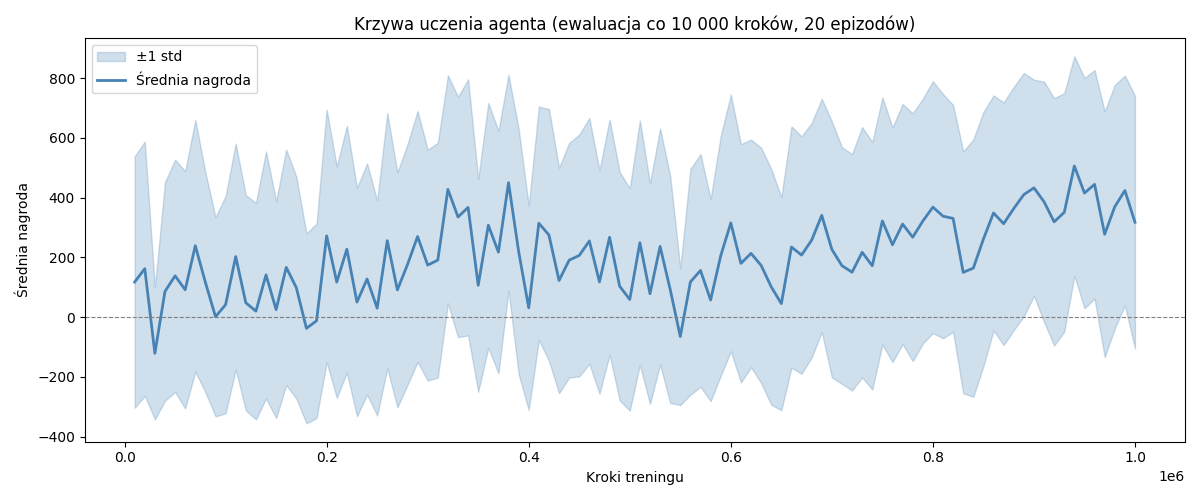

In [8]:
from IPython.display import Image

Image(filename='logs/plot.png')

### Eksperymenty

Został przeprowadzony eksperyment, by sprawdzić, jak nasz model się sprawuje podczas 200 gier.

In [4]:
import gymnasium as gym
from stable_baselines3 import PPO
import os
import CatchBrains
import numpy as np
env = gym.make("CatchBrains/CatchBrains", render_mode=None)
model = PPO.load("best_model")
N = 200
wins = 0
scores = []
lives = []
lives_when_won = []
for episode in range(N):
    obs, _ = env.reset()
    total_reward = 0.0
    done = False

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated

    print(f"Episode {episode + 1:2d}  reward={total_reward:8.1f}  score={info['score']:.0f}  lives={info['lives']}")
    if info['score'] >= 100:
        wins += 1
        lives_when_won.append(info['lives'])
    scores.append(info['score']) 
    lives.append(info['lives'])
env.close()

print(f"Liczba wygranych: {wins}, średni score: {np.sum(scores) / N}, średnia liczba pozostałych żyć: {np.sum(lives)/N}, średnia liczba pozostałych żyć, gdy wygrał: {np.sum(lives_when_won)/wins}")

Zwycięstwo! Osiągnięto limit punktów.
Episode  1  reward=   423.9  score=100  lives=5
Episode  2  reward=   427.6  score=60  lives=0
Zwycięstwo! Osiągnięto limit punktów.
Episode  3  reward=   469.1  score=100  lives=5
Zwycięstwo! Osiągnięto limit punktów.
Episode  4  reward=   515.7  score=100  lives=3
Zwycięstwo! Osiągnięto limit punktów.
Episode  5  reward=   451.5  score=100  lives=2
Zwycięstwo! Osiągnięto limit punktów.
Episode  6  reward=   378.2  score=100  lives=4
Zwycięstwo! Osiągnięto limit punktów.
Episode  7  reward=   331.2  score=100  lives=3
Episode  8  reward=   346.8  score=60  lives=0
Zwycięstwo! Osiągnięto limit punktów.
Episode  9  reward=   483.3  score=100  lives=1
Zwycięstwo! Osiągnięto limit punktów.
Episode 10  reward=   402.7  score=100  lives=3
Zwycięstwo! Osiągnięto limit punktów.
Episode 11  reward=   505.4  score=100  lives=4
Episode 12  reward=   202.6  score=50  lives=0
Zwycięstwo! Osiągnięto limit punktów.
Episode 13  reward=   405.7  score=100  lives=2

Okazało się, że nasz agent wygrywał około 80% gier. Zaobserwowałyśmy, że agent dość bał się innych części ciała, natomiast pewnie szedł po upragnione mózgi. Oprócz tego zostały wykonane lekkie statyski.

C:\Users\kalin\AppData\Local\Temp\ipykernel_27492\2821546017.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=lives_when_won, palette="viridis")


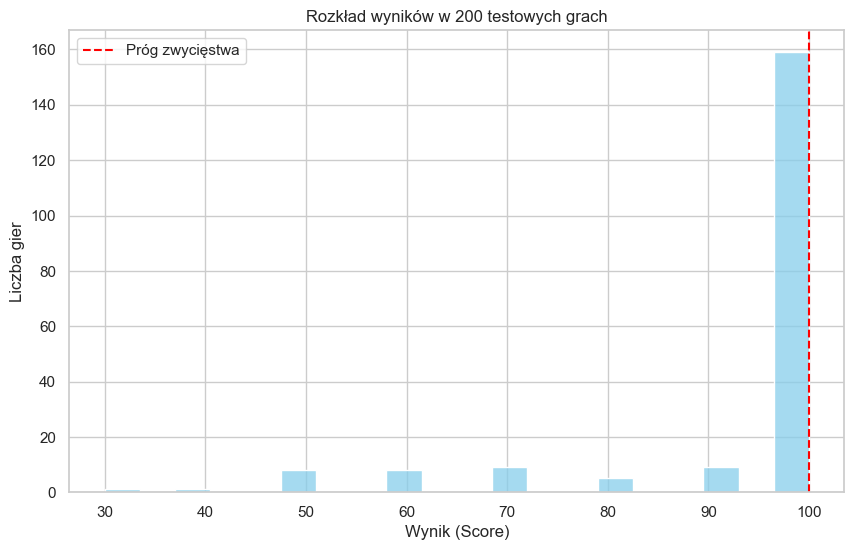

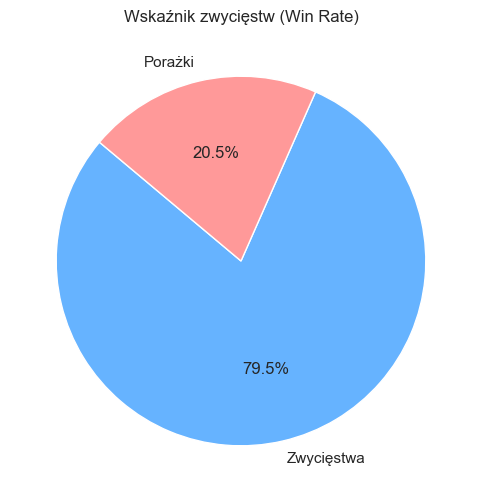

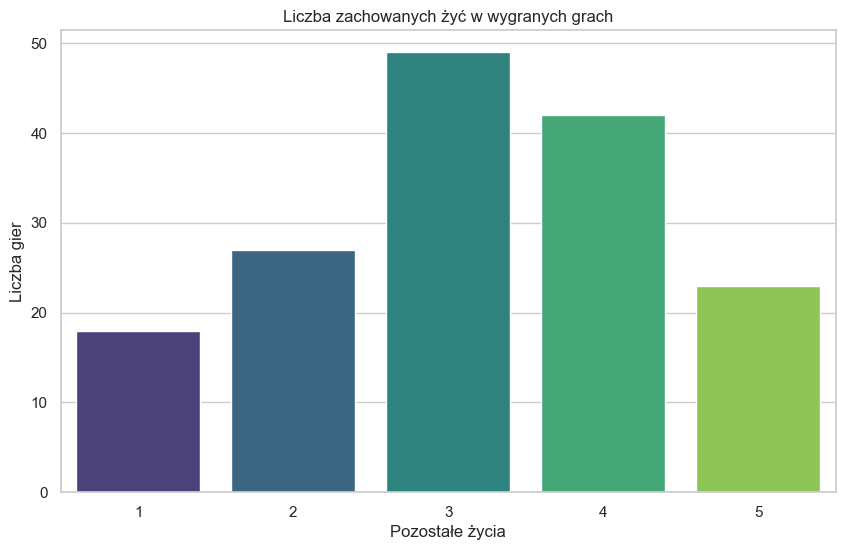

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

plt.figure()
sns.histplot(scores, bins=20, kde=False, color='skyblue')
plt.axvline(100, color='red', linestyle='--', label='Próg zwycięstwa')
plt.title('Rozkład wyników w 200 testowych grach')
plt.xlabel('Wynik (Score)')
plt.ylabel('Liczba gier')
plt.legend()
plt.savefig('histogram_scores.png')

plt.figure()
labels = ['Zwycięstwa', 'Porażki']
sizes = [wins, N - wins]
colors = ['#66b3ff', '#ff9999']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Wskaźnik zwycięstw (Win Rate)')
plt.savefig('win_rate_pie.png')

if lives_when_won:
    plt.figure()
    sns.countplot(x=lives_when_won, palette="viridis")
    plt.title('Liczba zachowanych żyć w wygranych grach')
    plt.xlabel('Pozostałe życia')
    plt.ylabel('Liczba gier')
    plt.savefig('lives_distribution.png')

plt.show()

## Tryb graficzny

Oto krótkie pokazanie naszego trybu graficznego.

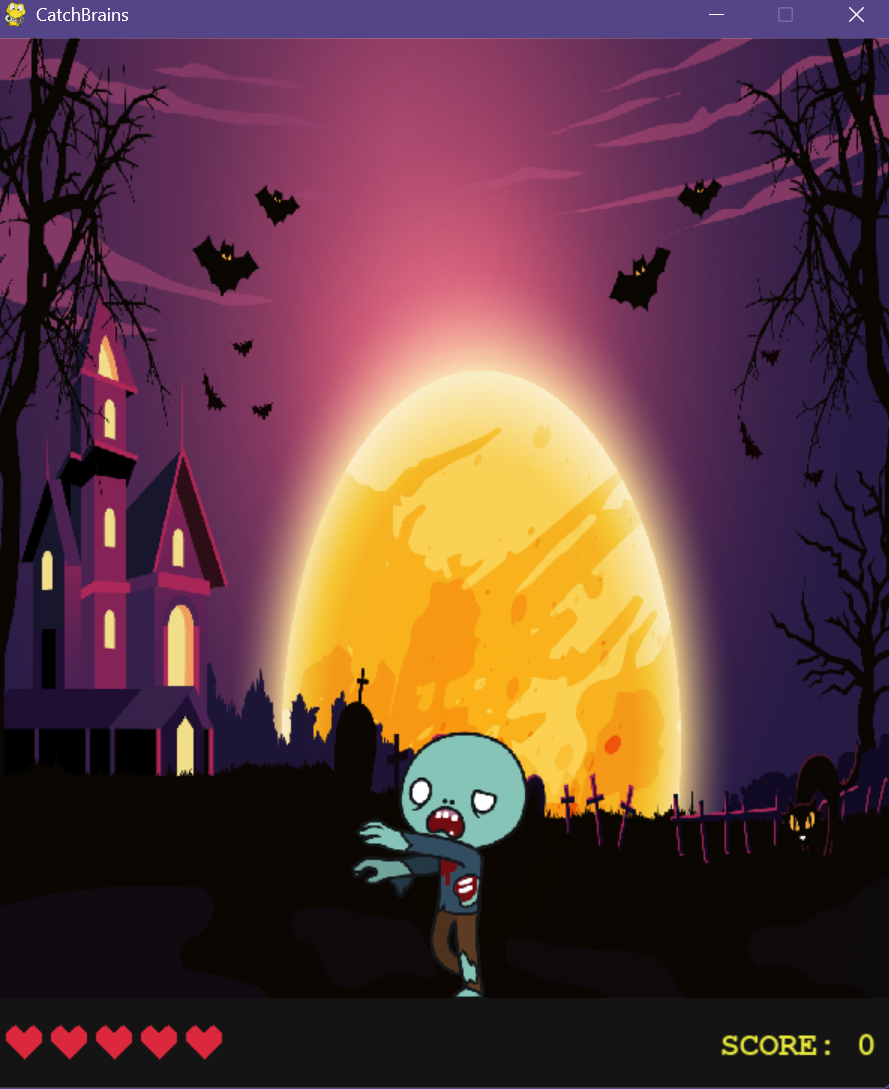

In [17]:
Image(filename='images/zombie1.png', width=400)

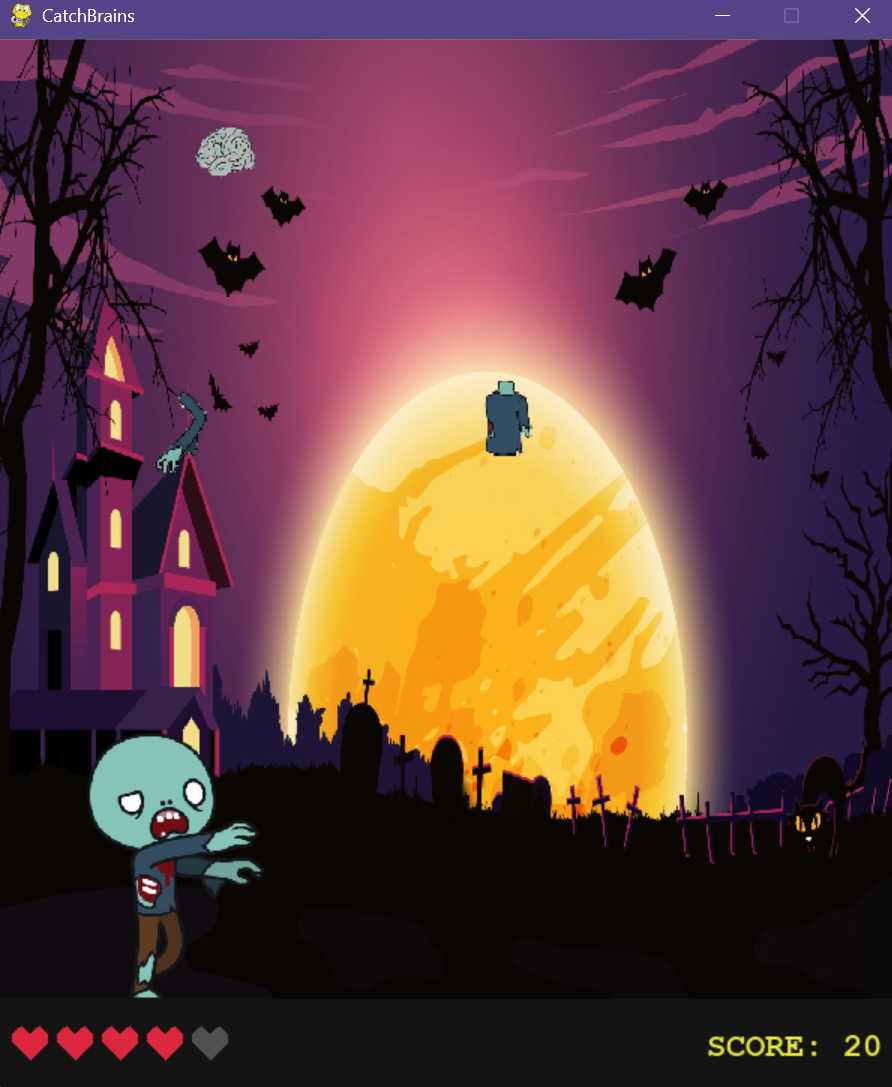

In [16]:
Image(filename='images/zombie2.png', width=400)

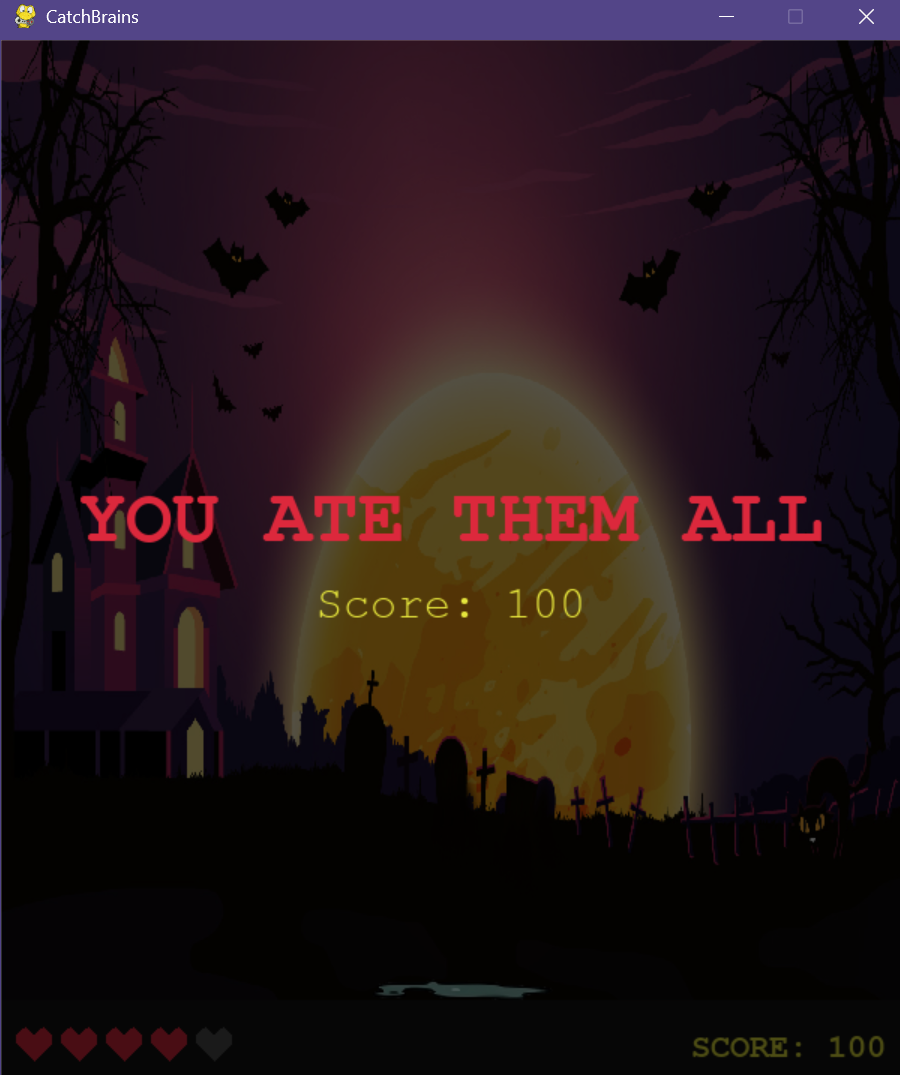

In [18]:
Image(filename='images/zombie3.png', width=400)